# Análisis de Sentimientos en Publicaciones de Redes Sociales con Redes Neuronales

Lucho <br> May|2023
You Can't Always Get What You Want by The Rolling Stones

Este conjunto de datos consta de unos pocos millones de reseñas de clientes de Amazon (texto de entrada) y calificaciones por estrellas (etiquetas de salida), con el objetivo de aprender a entrenar **fastText** para análisis de sentimientos.

La idea aquí es que el conjunto de datos no sea solo un ejemplo simple, sino que contenga **datos reales de negocio a una escala razonable**, y que aun así pueda entrenarse en cuestión de minutos en una computadora portátil modesta.

Dataset: https://www.kaggle.com/datasets/bittlingmayer/amazonreviews/data

## Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bz2
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint
from tensorflow.keras.layers import (Bidirectional, Dense, Dropout, Embedding,SpatialDropout1D,BatchNormalization, 
                                    GRU, LSTM, LayerNormalization, SimpleRNN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.metrics import Precision, Recall, AUC

from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, 
                            roc_curve, precision_recall_curve,classification_report, confusion_matrix)

from sklearn.model_selection import train_test_split

## Import Packages

In [2]:
# Cargar un subconjunto de los datos de entrenamiento
with bz2.BZ2File(r"E:\Trabajo\train.ft.txt.bz2") as f:
    training_data = [f.readline().decode('utf-8').strip() for _ in range(3000)]

# Cargar un subconjunto de los datos de prueba
with bz2.BZ2File(r"E:\Trabajo\test.ft.txt.bz2") as f:
    test_data = [f.readline().decode('utf-8').strip() for _ in range(1000)]

# Imprimir el tamaño de los subconjuntos
print("Tamaño del subconjunto de entrenamiento:", len(training_data))
print("Tamaño del subconjunto de prueba:", len(test_data))

Tamaño del subconjunto de entrenamiento: 3000
Tamaño del subconjunto de prueba: 1000


### Preparacion del dataset

In [3]:
training_data[0]

'__label__2 Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^'

In [4]:
# Extraer etiquetas y textos del conjunto de entrenamiento
training_labels = []
training_texts = []

for line in training_data:
    label = int(re.findall(r'__label__(\d)', line)[0])
    text = re.sub(r'__label__\d\s+', '', line)
    training_labels.append(0 if label == 1 else 1)  # Convertir a binario
    training_texts.append(text)

# Extraer etiquetas y textos del conjunto de prueba
test_labels = []
test_texts = []

for line in test_data:
    label = int(re.findall(r'__label__(\d)', line)[0])
    text = re.sub(r'__label__\d\s+', '', line)
    test_labels.append(0 if label == 1 else 1)
    test_texts.append(text)

In [5]:
test_labels[:20]

[1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1]

#### Limpieza de texto

In [6]:
# Descargar las stopwords si no están descargadas
nltk.download('stopwords')

def clean_text(text):
    """Limpia el texto: convierte a minúsculas, elimina stopwords y aplica stemming."""
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    
    # Convertir a minúsculas
    text = text.lower()
    
    # Eliminar caracteres no alfabéticos (mantener espacios)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenizar, eliminar stopwords y aplicar stemming
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    # Unir las palabras nuevamente en un solo string
    return " ".join(words)

# Aplicar la función de limpieza a los textos de entrenamiento y prueba
training_texts = [clean_text(text) for text in training_texts]
test_texts = [clean_text(text) for text in test_texts]

[nltk_data] Downloading package stopwords to C:\Users\Lupin
[nltk_data]     III\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
training_texts[0]

'stune even nongam sound track beauti paint seneri mind well would recomend even peopl hate vid game music play game chrono cross game ever play best music back away crude keyboard take fresher step grate guitar soul orchestra would impress anyon care listen'

#### Tokenizacion

In [8]:
# Tokenización y padding
max_words = 1000  # Número máximo de palabras a considerar (vocabulario)
max_sequence_length = 100  # Longitud máxima de las secuencias

# Crear el tokenizador con el límite de palabras
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(training_texts)  # Ajustar el tokenizador al texto de entrenamiento

# Convertir los textos en secuencias numéricas
X_train = tokenizer.texts_to_sequences(training_texts)
X_test = tokenizer.texts_to_sequences(test_texts)

# Rellenar (pad) las secuencias para que todas tengan la misma longitud
X_train = pad_sequences(X_train, maxlen=max_sequence_length)
X_test = pad_sequences(X_test, maxlen=max_sequence_length)


In [9]:
X_train = np.array(X_train)
print(X_train.shape)
X_test = np.array(X_test)
print(X_test.shape)
y_train = np.array(training_labels)
print(y_train.shape)
y_test = np.array(test_labels)
print(y_test.shape)

(3000, 100)
(1000, 100)
(3000,)
(1000,)


#### Entrenamiento

In [10]:
# Definimos un modelo RNN mejorado
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Aumentamos el tamaño de los vectores de embedding
    SimpleRNN(128, return_sequences=True, dropout=0.3),  # Capa RNN con dropout y retorno de secuencias
    LayerNormalization(),  # Normalización para mejorar la estabilidad del entrenamiento
    SimpleRNN(128, dropout=0.3),  # Segunda capa RNN con dropout
    LayerNormalization(),  # Otra normalización
    Dropout(0.3),  # Dropout adicional para prevenir overfitting
    Dense(64, activation="relu"),  # Capa densa intermedia con activación ReLU
    Dropout(0.2),  # Dropout adicional
    Dense(1, activation='sigmoid')  # Capa de salida para clasificación binaria
])

# Compilamos el modelo con una tasa de aprendizaje baja
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')])

# Definimos early stopping para evitar overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

C:\Users\Lupin III\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# Definir un modelo RNN mejorado
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Aumentar tamaño del embedding
    SimpleRNN(128, return_sequences=True, dropout=0.3,recurrent_dropout=0.2),  # Capa RNN con dropout
    LayerNormalization(),  # Normalización para mayor estabilidad
    SimpleRNN(128, dropout=0.3,recurrent_dropout=0.2),  # Segunda capa RNN
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Capa densa adicional
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Clasificación binaria
])

# Compilar el modelo con métricas adicionales
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=5e-5),
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

# Callbacks mejorados
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=50,
    min_lr=1e-7,
    verbose=1
)

model.summary()

In [11]:
# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5080 - auc: 0.5072 - loss: 0.8592 - precision: 0.4836 - recall: 0.3991 - val_accuracy: 0.4960 - val_auc: 0.4970 - val_loss: 0.7540 - val_precision: 0.4977 - val_recall: 0.4382
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4937 - auc: 0.4878 - loss: 0.8510 - precision: 0.4599 - recall: 0.3962 - val_accuracy: 0.4850 - val_auc: 0.4892 - val_loss: 0.7429 - val_precision: 0.4868 - val_recall: 0.4761
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5301 - auc: 0.5240 - loss: 0.8029 - precision: 0.4897 - recall: 0.4629 - val_accuracy: 0.4930 - val_auc: 0.4840 - val_loss: 0.7359 - val_precision: 0.4946 - val_recall: 0.4562
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5108 - auc: 0.5063 - loss: 0.8069 - precision: 0.4738 - recall: 0.4250 - val_accuracy: 0.4970 - val_auc: 0.4865 - val_loss: 0.7270 - val_precision: 0.4990 - val_recall: 0.4741
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - a

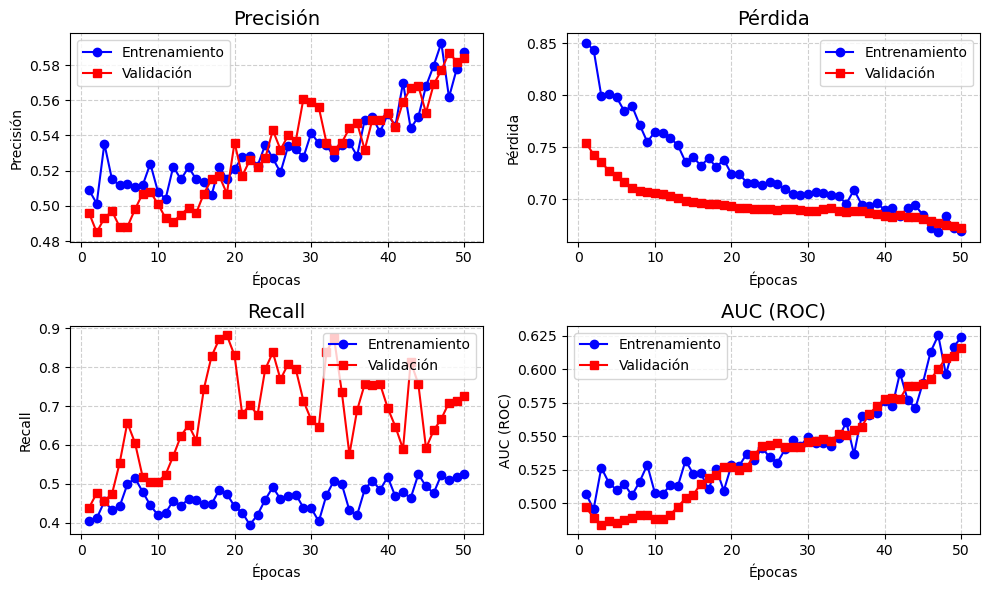

In [12]:
hist = history.history
epochs = range(1, len(hist['accuracy']) + 1)

plt.figure(figsize=(10,6))
metrics = [
    ('accuracy', 'Precisión'),
    ('loss', 'Pérdida'),
    ('recall', 'Recall'),
    ('auc', 'AUC (ROC)')
]

for i, (metric, title) in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.plot(epochs, hist[metric], 'b-o', label='Entrenamiento')
    plt.plot(epochs, hist[f'val_{metric}'], 'r-s', label='Validación')
    plt.title(title, fontsize=14)
    plt.xlabel('Épocas')
    plt.ylabel(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step

Classification Report:
              precision    recall  f1-score   support

    Negativo       0.61      0.44      0.51       498
    Positivo       0.57      0.73      0.64       502

    accuracy                           0.58      1000
   macro avg       0.59      0.58      0.58      1000
weighted avg       0.59      0.58      0.58      1000



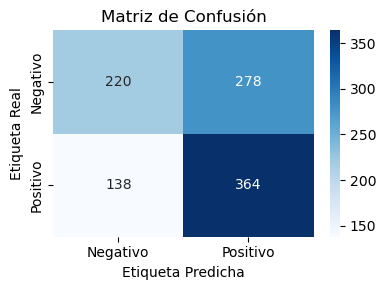

In [13]:
# Realizar predicciones
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Asegura tipo entero

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

# Graficar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
plt.show()

## Entrenamiento de LSTM

In [14]:
# Definimos un modelo 
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Aumentamos el tamaño de los vectores de embedding
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)),  # Capa LSTM bidireccional con dropout recurrente
    LayerNormalization(),  # Normalización para mejorar la estabilidad del entrenamiento
    Dropout(0.3),  # Dropout para reducir el sobreajuste
    Bidirectional(LSTM(128, recurrent_dropout=0.2)),  # Segunda capa LSTM bidireccional con dropout recurrente
    LayerNormalization(),  # Otra normalización
    Dropout(0.3),  # Más dropout para regularizar
    Dense(64, activation="relu"),  # Capa densa adicional con activación ReLU
    Dropout(0.2),  # Dropout adicional
    Dense(1, activation='sigmoid')  # Capa de salida para clasificación binaria
])

# Compilación del modelo con optimizador Adam y métricas adicionales
model.compile(
    loss='binary_crossentropy',  # Función de pérdida para clasificación binaria
    optimizer=Adam(learning_rate=5e-5),  # Tasa de aprendizaje baja
    metrics=[
        'accuracy',                     # Precisión global
        Precision(name='precision'),   # Precisión: TP / (TP + FP)
        Recall(name='recall'),         # Recall: TP / (TP + FN)
        AUC(name='auc')                # Área bajo la curva ROC
    ]
)

# Callback para detener el entrenamiento si no mejora la validación
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.summary()

C:\Users\Lupin III\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step - accuracy: 0.4856 - auc: 0.4899 - loss: 0.8763 - precision: 0.4532 - recall: 0.4793 - val_accuracy: 0.5540 - val_auc: 0.5724 - val_loss: 0.6958 - val_precision: 0.5814 - val_recall: 0.3984
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 26s 5s/step - accuracy: 0.5482 - auc: 0.5650 - loss: 0.7500 - precision: 0.5208 - recall: 0.5237 - val_accuracy: 0.6010 - val_auc: 0.6206 - val_loss: 0.6737 - val_precision: 0.5970 - val_recall: 0.6315
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.5577 - auc: 0.5650 - loss: 0.7341 - precision: 0.5306 - recall: 0.5335 - val_accuracy: 0.5960 - val_auc: 0.6433 - val_loss: 0.6714 - val_precision: 0.6713 - val_recall: 0.3825
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.5680 - auc: 0.5971 - loss: 0.6986 - precision: 0.5505 - recall: 0.4500 - val_accuracy: 0.6080 - val_auc: 0.6586 - val_loss: 0.6637 - val_precision: 0.6382 - val_recall: 0.5060
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step 

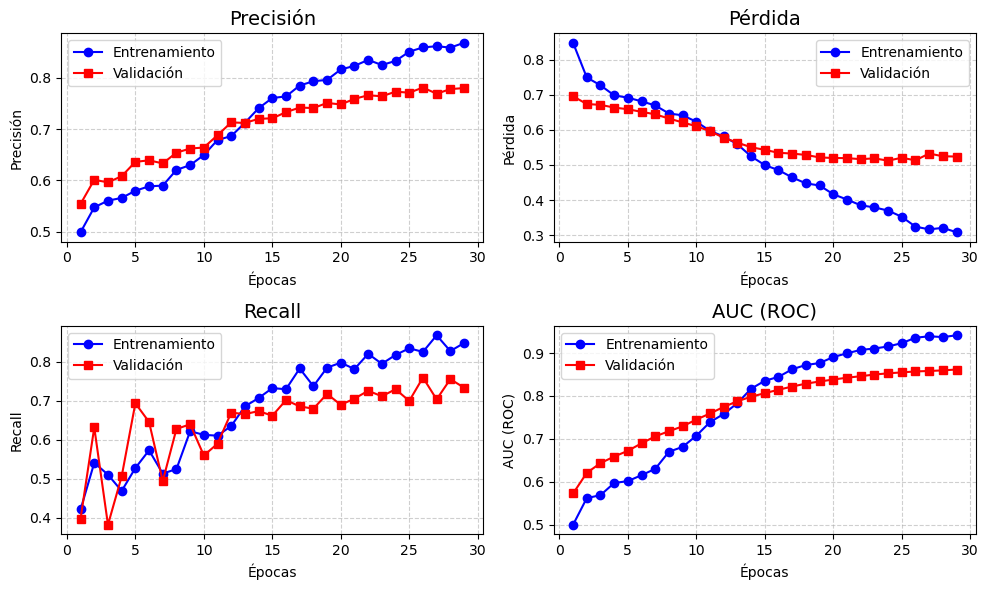

In [16]:
hist = history.history
epochs = range(1, len(hist['accuracy']) + 1)

plt.figure(figsize=(10,6))
metrics = [
    ('accuracy', 'Precisión'),
    ('loss', 'Pérdida'),
    ('recall', 'Recall'),
    ('auc', 'AUC (ROC)')
]

for i, (metric, title) in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.plot(epochs, hist[metric], 'b-o', label='Entrenamiento')
    plt.plot(epochs, hist[f'val_{metric}'], 'r-s', label='Validación')
    plt.title(title, fontsize=14)
    plt.xlabel('Épocas')
    plt.ylabel(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step

Classification Report:
              precision    recall  f1-score   support

    Negativo       0.75      0.82      0.78       498
    Positivo       0.80      0.73      0.76       502

    accuracy                           0.77      1000
   macro avg       0.78      0.77      0.77      1000
weighted avg       0.78      0.77      0.77      1000



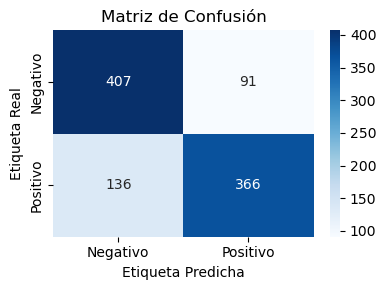

In [17]:
# Realizar predicciones
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Asegura tipo entero

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

# Graficar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
plt.show()

#### GRU

In [18]:
# Definimos un modelo GRU mejorado
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Aumentamos el tamaño de los vectores de embedding
    GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),  # Capa GRU con dropout en la entrada y en el estado recurrente
    LayerNormalization(),  # Normalización para mejorar la estabilidad del entrenamiento
    GRU(128, dropout=0.3, recurrent_dropout=0.2),  # Segunda capa GRU con dropout
    LayerNormalization(),  # Otra normalización
    Dropout(0.3),  # Dropout adicional para prevenir sobreajuste
    Dense(64, activation="relu"),  # Capa densa intermedia con activación ReLU
    Dropout(0.2),  # Dropout adicional
    Dense(1, activation='sigmoid')  # Capa de salida para clasificación binaria
])

# Compilamos el modelo con una tasa de aprendizaje baja
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Definimos early stopping para evitar sobreajuste (overfitting)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.summary()

C:\Users\Lupin III\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.4981 - loss: 1.0639 - val_accuracy: 0.5060 - val_loss: 0.9053
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4809 - loss: 1.0259 - val_accuracy: 0.5020 - val_loss: 0.8908
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.4845 - loss: 0.9814 - val_accuracy: 0.5040 - val_loss: 0.8865
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.4817 - loss: 0.9650 - val_accuracy: 0.5050 - val_loss: 0.8821
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.4862 - loss: 0.9324 - val_accuracy: 0.5060 - val_loss: 0.8768
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.4840 - loss: 0.9120 - val_accuracy: 0.5070 - val_loss: 0.8742
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5156 - loss: 0.8789 - val_accuracy: 0.5070 - val_loss: 0.8726
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5084 - loss: 0.8742 - val_accuracy: 0.5090 - val_loss: 0.8701
Epoch 9/

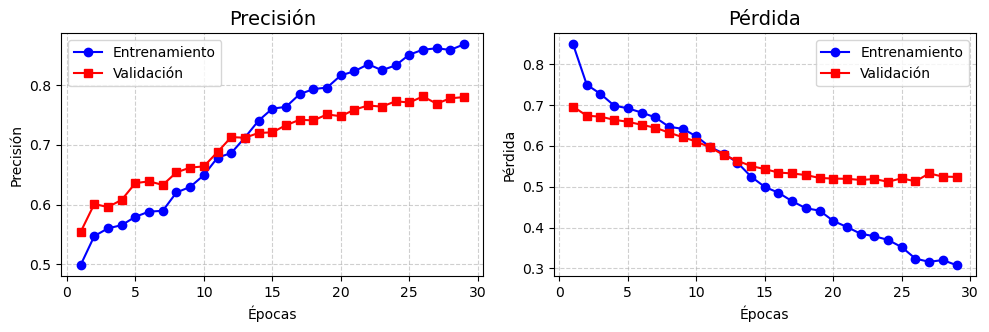

In [20]:
ist = history.history
epochs = range(1, len(hist['accuracy']) + 1)

plt.figure(figsize=(10,6))
metrics = [
    ('accuracy', 'Precisión'),
    ('loss', 'Pérdida'),
]

for i, (metric, title) in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.plot(epochs, hist[metric], 'b-o', label='Entrenamiento')
    plt.plot(epochs, hist[f'val_{metric}'], 'r-s', label='Validación')
    plt.title(title, fontsize=14)
    plt.xlabel('Épocas')
    plt.ylabel(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step

Classification Report:
              precision    recall  f1-score   support

    Negativo       0.54      0.32      0.40       498
    Positivo       0.52      0.74      0.61       502

    accuracy                           0.53      1000
   macro avg       0.53      0.53      0.50      1000
weighted avg       0.53      0.53      0.51      1000



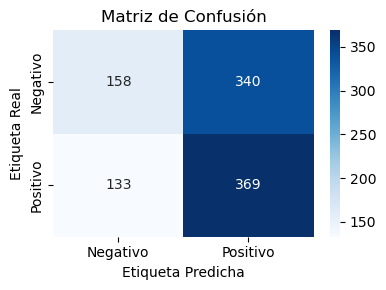

In [21]:
# Realizar predicciones
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)  # Asegura tipo entero

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

# Graficar la matriz de confusión
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
plt.show()

#### Sistema de Detencion

In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text, model, tokenizer, max_sequence_length=100):
    # limpiar el texto
    text = clean_text(text)
    
    # Convertir el texto en secuencia
    sequence = tokenizer.texts_to_sequences([text])
    
    # Rellenar la secuencia para que tenga una longitud fija
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length)
    
    # Predecir el sentimiento
    prediction = model.predict(padded_sequence)[0][0]  # Extraer valor escalar
    
    # Determinar el sentimiento
    sentiment = "Positivo 😊" if prediction > 0.5 else "Negativo 😡"
    
    return sentiment, float(prediction)

# Ejemplo de uso:
test_sentences = [
    "I love this product! It's amazing.",
    "This is the worst service I have ever experienced.",
    "The movie was okay, not great but not terrible either."
]

for sentence in test_sentences:
    sentiment, confidence = predict_sentiment(sentence, model, tokenizer)
    print(f"Texto: {sentence}\nSentimiento Predicho: {sentiment} (Confianza: {confidence:.4f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Texto: I love this product! It's amazing.
Sentimiento Predicho: Negativo 😡 (Confianza: 0.2548)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Texto: This is the worst service I have ever experienced.
Sentimiento Predicho: Negativo 😡 (Confianza: 0.1097)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Texto: The movie was okay, not great but not terrible either.
Sentimiento Predicho: Negativo 😡 (Confianza: 0.1127)



In [23]:
model.save("lstm_model.h5")  # Guarda la arquitectura, los pesos y el optimizador

import pickle

# Guarda el tokenizador en un archivo usando pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)